In [1]:
import edes 
from edes.experiments import Experiment
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.circuits import dBm_to_Vp, dBm_to_W, Vp_to_dBm
from edes.modules.trap_drive.utils import beep
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
from edes.experiments.sequences.base import TipVoltageSweep, Sequence, RFPowerSweep, RigolAWGSweep, RFPowerSweepAWG, RFPowerSweepVolLinTipSwitched
from edes.experiments.devices.base import Instrument
from edes.modules.variable_attenuator import var_attn_utils
from edes.utils.file_handling import load_latest_data
from edes.utils.utils import beep_jupyter
from typing import TYPE_CHECKING

# 1. This code block ONLY runs in your IDE for auto-complete
# It is completely ignored when the code actually runs
if TYPE_CHECKING:
    from edes.experiments.devices.base import *
big_plt_font()

In [2]:
exp = Experiment('3layer_trapping_070626')

>>> ERROR connecting to RigolDG4062 at TCPIP::192.168.169.104::INSTR: VI_ERROR_RSRC_NFOUND (-1073807343): Insufficient location information or the requested device or resource is not present in the system.
>>> ERROR initializing device AWG: 'RigolDG4062' object has no attribute 'instrument'
>>> Connected to Agilent Technologies,34461A,MY53200916,A.01.08-02.22-00.08-00.35-01-01

>>> Connected to ARTIQ Zotino.
>>> Connected to RIGOL TECHNOLOGIES,DP832A,DP8B260200018,00.01.19

>>> ERROR connecting to Keithley2100 at USB0::1510::8448::1243106::0::INSTR: No device found.
>>> ERROR connecting to SiglentSPD3303X_E at TCPIP::192.168.169.101::INSTR: [Errno 104] Connection reset by peer
>>> Connected to Siglent Technologies,SSA3032X-R,SSA5PA1Q800415,3.2.2.6.0R10

>>> Connected to Valon at ASRL/dev/ttyUSB0::INSTR with frequency 1465000000.0 Hz and power 0 dBm.


In [4]:
exp.SSA.set_N_avg(16)
exp.SSA.set_freq_span(100e3)
exp.SSA.set_freq_center(176.19e6)
exp.SSA.set_div_scale(1)
# freq, data = exp.SSA.measure_freq_spectrum()
# plot(freq/1e6, data, xlabel='Frequency (MHz)', ylabel='Power (dBm)')

In [5]:
exp.list_devices()

['Agilent', 'DAC', 'FEtip_PSU', 'Keithley', 'LNA_PSU', 'SSA']

In [25]:
exp.FEtip_PSU.ramp_down(0)

In [48]:
tip_Vsweep = TipVoltageSweep(saving_dir=exp.saving_dir, 
                             V_start=700, V_stop=1200, V_step=50, R=200e6, 
                             N_avg=8, t_PSU_settle=2, t_meas_delay=0.2, 
                             FEtip_PSU=exp.FEtip_PSU, multimeter=exp.Agilent)

In [49]:
file = tip_Vsweep.run_save()

100%|███████████████████████████████████████████| 10/10 [01:04<00:00,  6.48s/it]


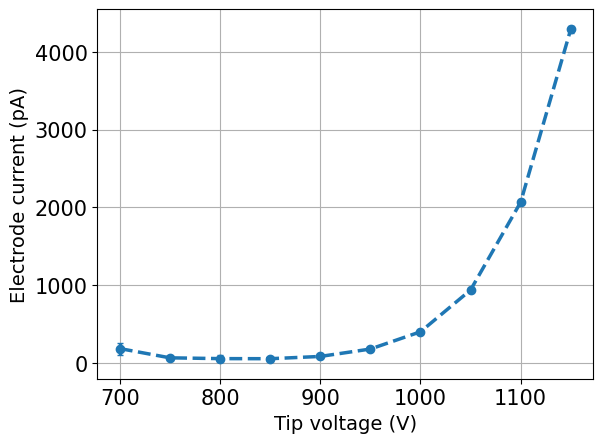

In [50]:
plot_errbar(file['all_V'], np.mean(file['all_I'], axis=1)*1e12, yerr=np.std(file['all_I'], axis=1)*1e12, fmt='.--', xlabel='Tip voltage (V)', ylabel='Electrode current (pA)')
# plt.yscale('log')

In [192]:
exp.SSA.select_mode('RTSA')
exp.SSA.set_N_avg(1)
exp.SSA.set_freq_span(10e3)
exp.SSA.set_freq_center(176.2190e6)
exp.SSA.set_div_scale(1)
exp.SSA.set_SWT(100e-3)
exp.SSA.set_RBW(100)
exp.SSA.set_ref_level(-65)
# freq, data = exp.SSA.measure_freq_spectrum()
# plot(freq/1e6, data, xlabel='Frequency (MHz)', ylabel='Power (dBm)')

In [20]:
exp.SSA.select_mode('SA')
exp.SSA.set_N_avg(1)
exp.SSA.set_freq_span(10e3)
exp.SSA.set_freq_center(176.2190e6)
exp.SSA.set_div_scale(5)
exp.SSA.set_SWT(100e-3)
exp.SSA.set_RBW(100)
exp.SSA.set_ref_level(-40)
# freq, data = exp.SSA.measure_freq_spectrum()
# plot(freq/1e6, data, xlabel='Frequency (MHz)', ylabel='Power (dBm)')

In [83]:
exp.Valon.set_frequency(1.465e9)
exp.Valon.set_power(0)
exp.Valon.output_off()

In [24]:
exp.SSA.select_mode('RTSA')

In [7]:
exp.Valon.set_frequency(1.465e9)

In [171]:
exp.Valon.output_on()

In [230]:
exp.Valon.output_off()

In [72]:
exp.DAC.set_multipoles(Ex=4, U2=-0.4)

RID: 9865
voltages loaded


In [218]:
exp.FEtip_PSU.ramp_up(1100)

In [227]:
exp.Valon.set_power(10)

In [228]:
exp.Valon.set_power(5)

In [229]:
exp.FEtip_PSU.ramp_down(0)

In [231]:
class RFPowerSweepAWGArbRamp(RFPowerSweepVolLinTipSwitched): 
    def __init__(self, name='RFPowerSweepAWGArbRamp', saving_dir=None,
                 P_min_dBm=-10, P_max_dBm =0, P_start_dBm=-9, P_hold_dBm=-9,
                 ramp_time=0.1, hold_time=0.05,
                 AWG=None, P_valon=5.0,
                 t_data_buffer=1, t_seq_gap=0.5, N_avg=5, 
                 V_on=1400, V_off=700, t_tip_settle=3,
                 SSA_freq_center=None, SSA_freq_span = None,
                 SSA_RBW = 30e3, 
                 Valon=None, SSA=None, FEtip_PSU=None,
                 display_progress=True,
                 **kwargs): 
        super().__init__(name, saving_dir=saving_dir, 
                         N_avg=N_avg, V_on=V_on, V_off=V_off, 
                         SSA_freq_center=SSA_freq_center, SSA_freq_span=SSA_freq_span, 
                         SSA_RBW=SSA_RBW, SSA_SWT=t_tip_settle+ramp_time+hold_time+t_data_buffer, 
                         Valon=Valon, SSA=SSA, FEtip_PSU=FEtip_PSU, 
                         **kwargs)
        self.display_progress = display_progress
        self.t_tip_settle = t_tip_settle
        self.t_data_buffer = t_data_buffer
        self.t_seq_gap = t_seq_gap
        self.ramp_time = ramp_time 
        self.hold_time = hold_time
        self.flat_time = t_tip_settle
        self.P_min_dBm = P_min_dBm
        self.P_max_dBm = P_max_dBm
        self.P_flat_dBm = P_start_dBm
        self.P_hold_dBm = P_hold_dBm
        self.P_valon = P_valon
        V_min = var_attn_utils.get_vctrl(self.P_min_dBm, P_in=P_valon)
        V_max = var_attn_utils.get_vctrl(self.P_max_dBm, P_in=P_valon)
        V_flat = var_attn_utils.get_vctrl(self.P_flat_dBm, P_in=P_valon)
        V_hold = var_attn_utils.get_vctrl(self.P_hold_dBm, P_in=P_valon)
        self.AWG_sweep = RigolAWGSweep(v_min=V_min, v_max=V_max, v_hold=V_hold, v_flat=V_flat,
                                       flat_time=t_tip_settle, ramp_time=ramp_time, 
                                       hold_time=hold_time, AWG=AWG, channel=AWG.channel)
        self.Valon.set_power(self.P_valon)
        self.Valon.output_on()

    def run(self):
        self.SSA_init(self.SSA_freq_center, self.SSA_freq_span, self.SSA_RBW, self.SSA_SWT)
        self.FEtip_PSU.ramp_up(self.V_off)
        self.SSA.clear_averaging()
        self.SSA.trigger_on()
        self.AWG_sweep.run()
        time.sleep(self.AWG_sweep.running_time)
        self.SSA.get_trace()
        time.sleep(1)
        all_meas = []
        all_t_sweep_start = [] 
        all_t_sweep_end = []
        all_t_tip_on = [] 
        all_t_tip_off = []
        all_t_seq_end = []

        for _ in self.progress_bar(range(self.N_avg), disable=(not self.display_progress)):

            t0 = time.time()
            self.FEtip_PSU.set_voltage(self.V_on)
            # time.sleep(self.t_tip_settle)
            t1 = time.time()
            self.AWG_sweep.run()
            time.sleep(self.AWG_sweep.running_time)
            t2 = time.time()
            # self.FEtip_PSU.set_voltage(self.V_off)
            t3 = time.time()
            time.sleep(self.t_data_buffer)
            data = self.SSA.get_trace()
            t4 = time.time()
            
            all_meas.append(data)
            all_t_sweep_start.append(t1)
            all_t_sweep_end.append(t2)
            all_t_tip_on.append(t0)
            all_t_tip_off.append(t3)
            all_t_seq_end.append(t4)
            time.sleep(self.t_seq_gap)

        self.FEtip_PSU.ramp_down(0)
        self.SSA.trigger_off()

        return {'all_meas': np.array(all_meas), 't_sweep_start': np.array(all_t_sweep_start)+self.t_tip_settle, 
                't_sweep_end': np.array(all_t_sweep_end), 't_tip_on': np.array(all_t_tip_on),
                't_tip_off': np.array(all_t_tip_off), 't_seq_end': np.array(all_t_seq_end)}

In [8]:
class RFPowerSweepOnOff(RFPowerSweepVolLinTipSwitched): 
    def __init__(self, name='RFPowerSweepOnOff', saving_dir=None,
                 P_load=10, P_detect=5, V_on=1050, V_off=600,
                 t_load=10, t_data=1, t_rest=1,
                 SSA_freq_center=None, SSA_freq_span = None,
                 SSA_RBW=30e3, N_avg=32,
                 Valon=None, SSA=None, FEtip_PSU=None,
                 display_progress=True,
                 **kwargs): 
        super().__init__(name, saving_dir=saving_dir, 
                         N_avg=N_avg, V_on=V_on, V_off=V_off, 
                         SSA_freq_center=SSA_freq_center, SSA_freq_span=SSA_freq_span, 
                         SSA_RBW=SSA_RBW, SSA_SWT=t_data, 
                         Valon=Valon, SSA=SSA, FEtip_PSU=FEtip_PSU, 
                         **kwargs)
        self.display_progress = display_progress
        self.P_load = P_load 
        self.P_detect = P_detect 
        self.t_load = t_load 
        self.t_data = t_data 
        self.t_rest = t_rest 

    def run(self):
        self.SSA.select_mode('SA')
        self.SSA_init(self.SSA_freq_center, self.SSA_freq_span, self.SSA_RBW, self.SSA_SWT)
        self.FEtip_PSU.ramp_up(self.V_off)
        self.SSA.clear_averaging()
        self.SSA.get_full_trace()
        all_meas = []
        for _ in self.progress_bar(range(self.N_avg), disable=(not self.display_progress)):

            self.FEtip_PSU.set_voltage(self.V_on)
            self.Valon.output_on() 
            self.Valon.set_power(self.P_load)
            time.sleep(self.t_load)
            self.SSA.clear_averaging() 
            # self.SSA.get_full_trace()
            self.Valon.set_power(self.P_detect)
            data = self.SSA.get_full_trace()
            all_meas.append(data)
            self.FEtip_PSU.set_voltage(self.V_off)
            self.Valon.output_off()
            time.sleep(self.t_rest)

        self.FEtip_PSU.ramp_down(0)
        self.Valon.output_off()
        self.SSA.clear_averaging()

        return {'all_meas': np.array(all_meas)}

In [22]:
RF_sweep = RFPowerSweepOnOff(saving_dir=exp.saving_dir, 
                             P_load=10, P_detect=5, V_on=1050, V_off=600,
                             t_load=30, t_data=0.1, t_rest=10,
                             SSA_freq_center=176.2190e6, SSA_freq_span=0,
                             SSA_RBW=1e3, N_avg=32,
                             Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                             display_progress=True)

In [266]:
file = RF_sweep.run_save()

100%|███████████████████████████████████████████| 50/50 [33:32<00:00, 40.24s/it]


In [272]:
all_U2 = [-1, -0.7, -0.4, -0.2, 0.5, 1] 
all_Ex = [3, 2, 1, 0, -0.5, -1]
len(all_U2)*len(all_Ex)

36

In [278]:
exp.Valon.set_power(0)
exp.Valon.output_off()
exp.FEtip_PSU.ramp_down(0)

In [15]:
exp.SSA.set_div_scale(5)


In [24]:
all_U2 = [-1, -0.7, -0.4, -0.2, 0.5, 1] 
all_Ex = [0]
for Ex in all_Ex:
    for U2 in all_U2:
        RF_sweep.set_parameters(U2=U2)
        RF_sweep.set_parameters(Ex=Ex)
        exp.DAC.set_multipoles(Ex=Ex, U2=U2)
        file = RF_sweep.run_save()
        exp.DAC.ground_all() 
        time.sleep(60*5) 
exp.Valon.set_power(0)
exp.Valon.output_off()
exp.FEtip_PSU.ramp_down(0)
beep_jupyter()

RID: 9934
voltages loaded


100%|███████████████████████████████████████████| 32/32 [21:27<00:00, 40.24s/it]


RID: 9935
voltages loaded
RID: 9936
voltages loaded


100%|███████████████████████████████████████████| 32/32 [21:27<00:00, 40.24s/it]


RID: 9937
voltages loaded
RID: 9938
voltages loaded


...

RID: 9941
voltages loaded
RID: 9942
voltages loaded


100%|███████████████████████████████████████████| 32/32 [21:27<00:00, 40.24s/it]


RID: 9943
voltages loaded
RID: 9944
voltages loaded


100%|███████████████████████████████████████████| 32/32 [21:27<00:00, 40.24s/it]


RID: 9945
voltages loaded


In [28]:
class RFPowerSweepOnOffTipOff(RFPowerSweepVolLinTipSwitched): 
    def __init__(self, name='RFPowerSweepOnOff', saving_dir=None,
                 P_load=10, P_detect=5, V_on=1050, V_off=600,
                 t_load=10, t_data=1, t_rest=1,
                 SSA_freq_center=None, SSA_freq_span = None,
                 SSA_RBW=30e3, N_avg=32,
                 Valon=None, SSA=None, FEtip_PSU=None,
                 display_progress=True,
                 **kwargs): 
        super().__init__(name, saving_dir=saving_dir, 
                         N_avg=N_avg, V_on=V_on, V_off=V_off, 
                         SSA_freq_center=SSA_freq_center, SSA_freq_span=SSA_freq_span, 
                         SSA_RBW=SSA_RBW, SSA_SWT=t_data, 
                         Valon=Valon, SSA=SSA, FEtip_PSU=FEtip_PSU, 
                         **kwargs)
        self.display_progress = display_progress
        self.P_load = P_load 
        self.P_detect = P_detect 
        self.t_load = t_load 
        self.t_data = t_data 
        self.t_rest = t_rest 

    def run(self):
        self.SSA.select_mode('SA')
        self.SSA_init(self.SSA_freq_center, self.SSA_freq_span, self.SSA_RBW, self.SSA_SWT)
        self.FEtip_PSU.ramp_up(self.V_off)
        self.SSA.clear_averaging()
        self.SSA.get_full_trace()
        all_meas = []
        for _ in self.progress_bar(range(self.N_avg), disable=(not self.display_progress)):

            self.FEtip_PSU.set_voltage(self.V_on)
            self.Valon.output_on() 
            self.Valon.set_power(self.P_load)
            time.sleep(self.t_load)
            self.SSA.clear_averaging() 
            # self.SSA.get_full_trace()
            self.FEtip_PSU.set_voltage(self.V_off)
            self.Valon.set_power(self.P_detect)
            data = self.SSA.get_full_trace()
            all_meas.append(data)
            # self.FEtip_PSU.set_voltage(self.V_off)
            self.Valon.output_off()
            time.sleep(self.t_rest)

        self.FEtip_PSU.ramp_down(0)
        self.Valon.output_off()
        self.SSA.clear_averaging()

        return {'all_meas': np.array(all_meas)}

In [46]:
RF_sweep = RFPowerSweepOnOffTipOff(saving_dir=exp.saving_dir, 
                             P_load=10, P_detect=5, V_on=1150, V_off=900,
                             t_load=20, t_data=0.1, t_rest=1,
                             SSA_freq_center=176.2190e6, SSA_freq_span=0,
                             SSA_RBW=1e3, N_avg=20,
                             Valon=exp.Valon, SSA=exp.SSA, FEtip_PSU=exp.FEtip_PSU,
                             display_progress=True)

In [47]:
exp.SSA.set_N_avg(1)
exp.DAC.set_multipoles(Ex=0.5, U2=-0.4)
file = RF_sweep.run_save()
exp.Valon.output_off()
exp.FEtip_PSU.ramp_down(0)

RID: 9960
voltages loaded


100%|███████████████████████████████████████████| 20/20 [07:04<00:00, 21.23s/it]


In [61]:
exp.Valon.output_off()

In [51]:
exp.DAC.ground_all() 

RID: 9962
voltages loaded
